In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# 1. Load dataset MNIST 
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# 2. Normalisasi nilai piksel menjadi 0-1
train_images, test_images = train_images / 255.0, test_images / 255.0

# 3. Reshape data agar sesuai input CNN (Batch, Height, Width, Channels)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

model = models.Sequential([
    # Layer Konvolusi pertama
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Layer Konvolusi kedua
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Meratakan data
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(64, activation='relu'),
    
    # Output Layer: Fixed: 10 neurons
    layers.Dense(10, activation='softmax')
])

# Kompilasi model 
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Melatih model (Training)
print("Memulai pelatihan...")
model.fit(train_images, train_labels, epochs=5)

# Evaluasi hasil pada data uji
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nAkurasi pada data uji: {test_acc*100:.2f}%')

I0000 00:00:1777358187.425728   22720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777358187.752102   22720 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777358191.037508   22720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/var/home/awchan/Project/Machine-Learning/tf_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777358330.767496   22720 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Memulai pelatihan...
Epoch 1/5


W0000 00:00:1777358331.368243   22720 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9579 - loss: 0.1371
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9855 - loss: 0.0459
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9900 - loss: 0.0319
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9921 - loss: 0.0250
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9943 - loss: 0.0186
313/313 - 2s - 6ms/step - accuracy: 0.9855 - loss: 0.0460

Akurasi pada data uji: 98.55%


## Klasifikasi Angka CNN

In [3]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 35.4 MB/s  0:00:00 31.7 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 52.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 28.3 MB/s  0:00:009.0 MB/s eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical

In [7]:
#Membuat dataset
(X_train,y_train), (X_test,y_test) = mnist.load_data()

Text(0.5, 0.98, 'Data Latih Sebelum CNN')

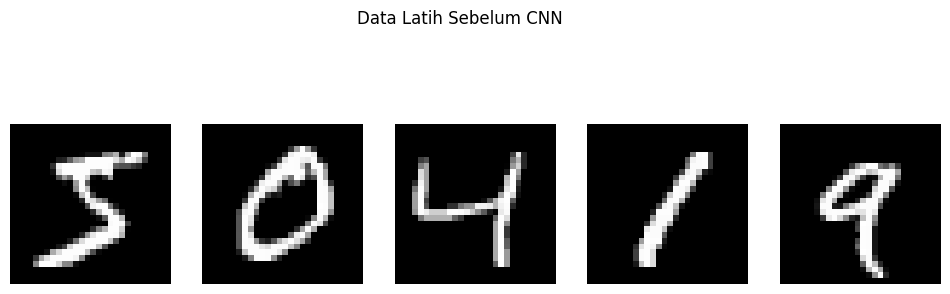

In [11]:
#Visualisasi Data sebelum proses CNN
plt.figure(figsize=(12,4))
for i in range(5):
    plt. subplot (1,5,i+1)
    plt.imshow(X_train[i], cmap='grey')
    plt.axis( 'off')
plt.suptitle('Data Latih Sebelum CNN')

In [12]:
#Normalisasi reshape data
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [17]:
#Membangun model CNN
model = Sequential([
    Conv2D(32,(3,3), activation ='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation ='relu'),
    Dense(10, activation ='softmax')
])

In [20]:
#Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
#Melatih model.
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
plt.tight_layout()

Epoch 1/5


W0000 00:00:1777361981.161081   22720 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8701 - loss: 0.4325

W0000 00:00:1777361994.351372   22720 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9361 - loss: 0.2136 - val_accuracy: 0.9747 - val_loss: 0.0902
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9799 - loss: 0.0658 - val_accuracy: 0.9808 - val_loss: 0.0665
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9836 - val_loss: 0.0571
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9902 - loss: 0.0318 - val_accuracy: 0.9813 - val_loss: 0.0679
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9935 - loss: 0.0221 - val_accuracy: 0.9852 - val_loss: 0.0549


<Figure size 640x480 with 0 Axes>

In [23]:
from os import X_OK
#Evaluasi model pada data uji
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'test_accuracy; {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9861 - loss: 0.0446
test_accuracy; 0.9861


In [24]:
#Prediksi dan Visualisasi model
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


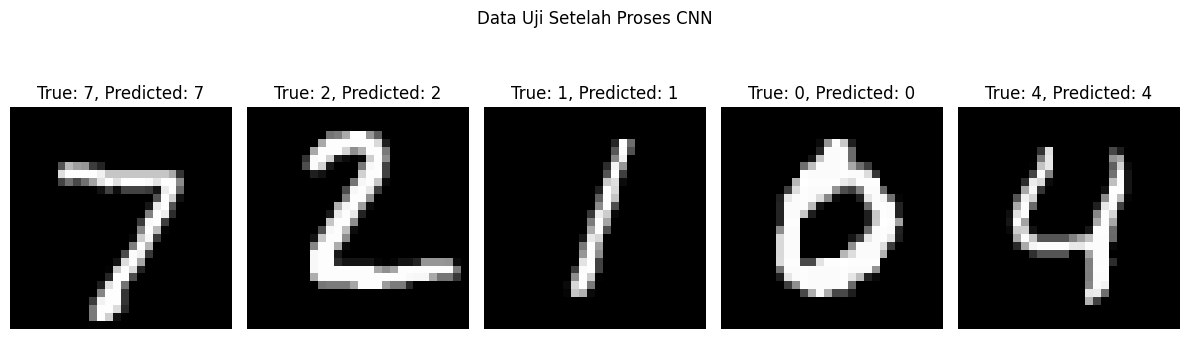

In [27]:
#Visualisasi Data setelah proses CNN
num_samples = 5
plt.figure(figsize=(12,4))
for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='grey')
    true_labels = np.argmax(y_test[i])
    predicted_labels = np.argmax(predictions[i])
    plt.title(f"True: {true_labels}, Predicted: {predicted_labels}")
    plt.axis('off')
plt.suptitle('Data Uji Setelah Proses CNN')

plt.tight_layout()
plt.show()